In [44]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

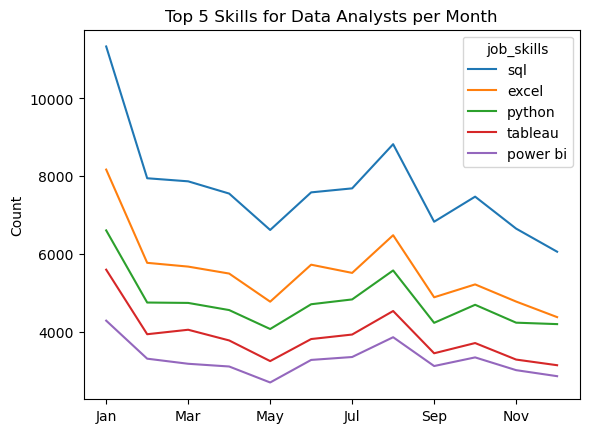

In [3]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()
# create a new column for month number
df_da['job_posted_month_no'] = df_da['job_posted_date'].dt.month

# Explode the job_skills column and pivot
df_da_explode= df_da.explode('job_skills')
df_da_pivot = df_da_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

# sort the skills by count
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_pivot = df_da_pivot.drop('Total')

# Use month names for plotting
df_da_pivot = df_da_pivot.reset_index()
df_da_pivot['job_posted_month'] = df_da_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_pivot = df_da_pivot.set_index('job_posted_month')
df_da_pivot = df_da_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_da_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

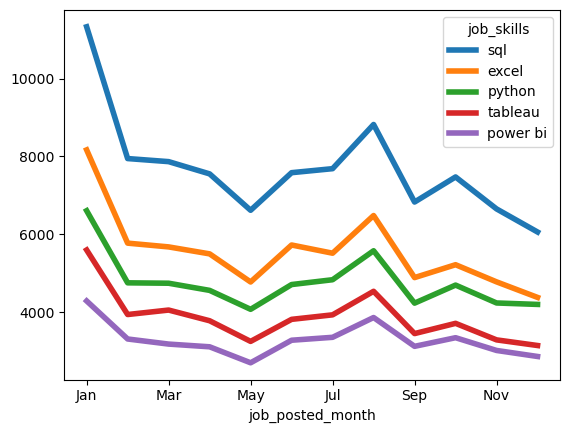

In [4]:
# make the line thicker:

df_da_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=4
)

plt.show()

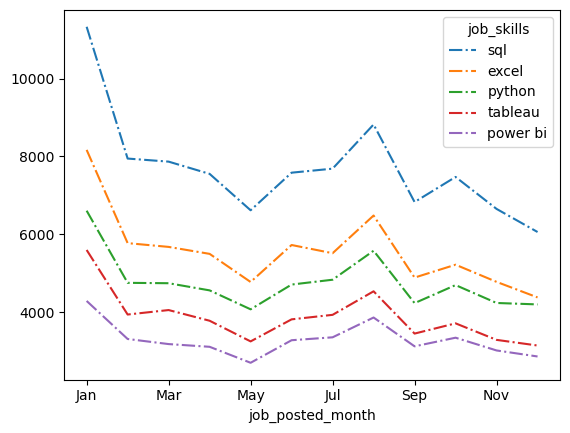

In [13]:
# change line style

df_da_pivot.iloc[:,:5].plot(
    kind='line',
    linestyle='-.' # options '-' '-- '-.' ':'
)
plt.show()

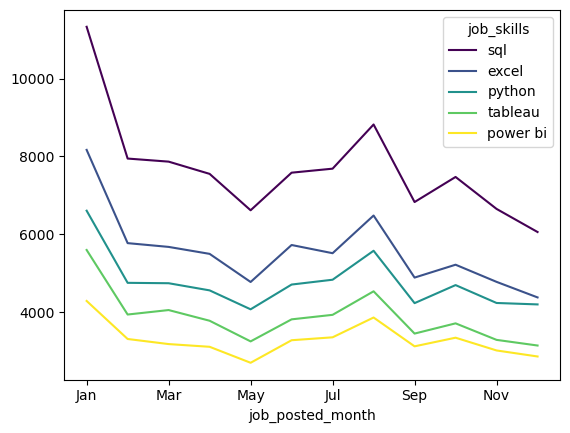

In [22]:
df_da_pivot.iloc[:,:5].plot(
    kind='line',    
    linestyle = '-', # options '-' '-- '-.' ':'
    colormap = 'viridis'
)
plt.show()

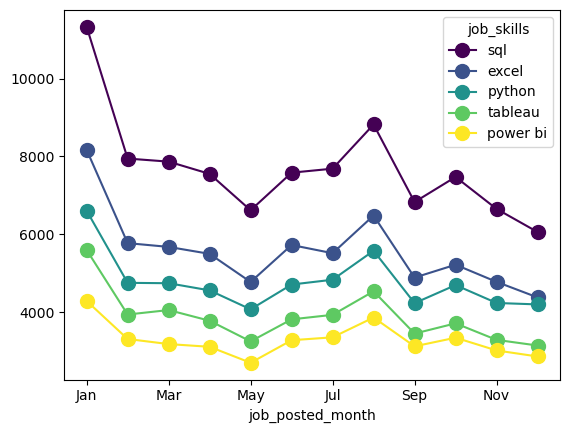

In [27]:
df_da_pivot.iloc[:,:5].plot(
    kind='line',
    
    linestyle = '-', # options '-' '-- '-.' ':'
    colormap = 'viridis',
    marker = 'o', # options 'o' 's' '^' 'D'
   markersize = 10
)
plt.show()

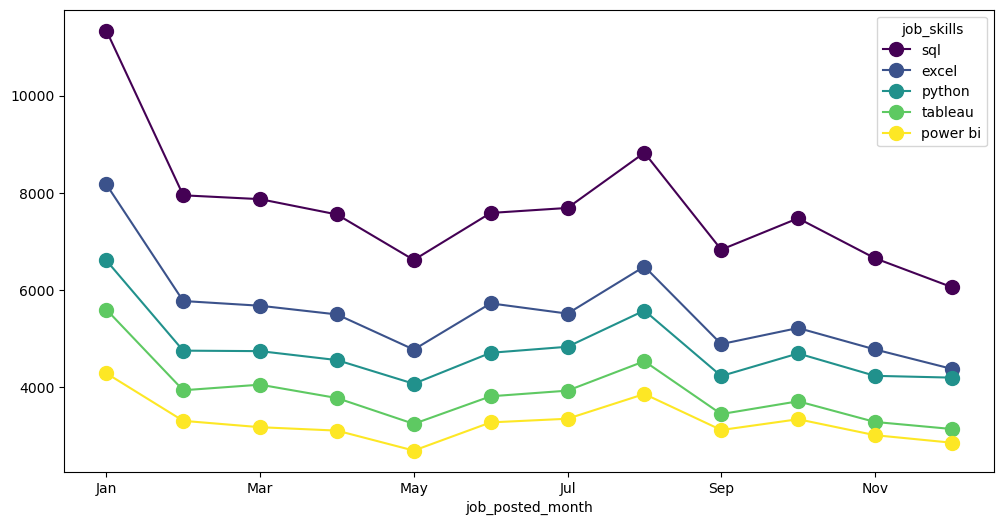

In [28]:
df_da_pivot.iloc[:,:5].plot(
    kind='line',
    figsize=(12,6),
    linestyle = '-', # options '-' '-- '-.' ':'
    colormap = 'viridis',
    marker = 'o', # options 'o' 's' '^' 'D'
   markersize = 10
)
plt.show()

## Customizing Scatter Plot

In [29]:
# Explode the 'job_skills' into individual rows
df_exploded = df_da.explode('job_skills')

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

In [45]:
skill_stats.head(20)

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


In [34]:
from adjustText import adjust_text

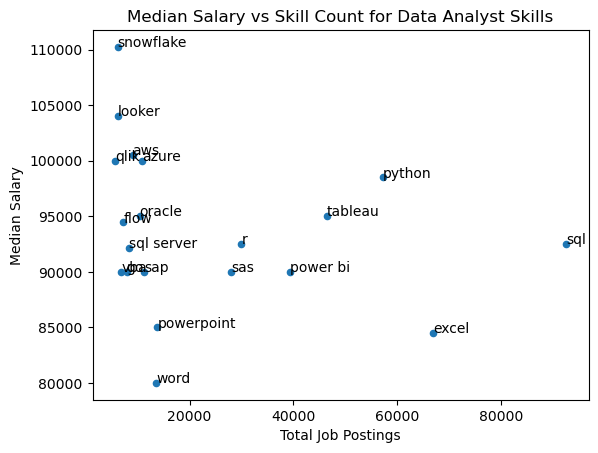

In [54]:
skill_stats.plot(kind='scatter',x='skill_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
    
plt.title('Median Salary vs Skill Count for Data Analyst Skills')
plt.xlabel('Total Job Postings')
plt.ylabel('Median Salary') 
plt.show()


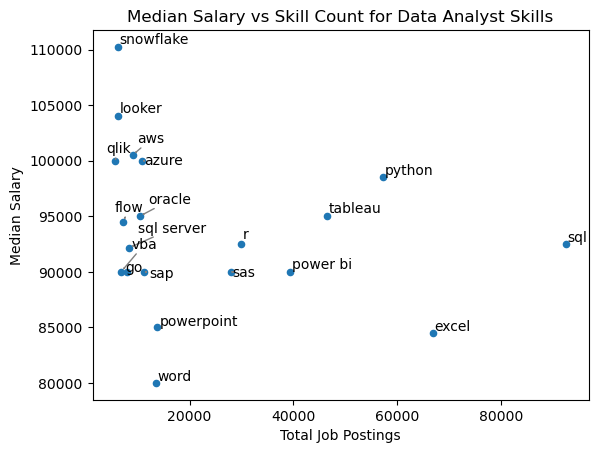

In [53]:


skill_stats.plot(kind='scatter',x='skill_count', y='median_salary')
text = []
for i, txt in enumerate(skill_stats.index):
    text.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))
    
adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title('Median Salary vs Skill Count for Data Analyst Skills')
plt.xlabel('Total Job Postings')
plt.ylabel('Median Salary') 
plt.show()
